<a href="https://colab.research.google.com/github/mohantyk/txt2img/blob/main/Chap5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install diffusers

In [2]:
import torch
import matplotlib.pyplot as plt
import PIL
import numpy as np
import math
import diffusers
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader

In [3]:
!git clone https://github.com/markhliu/txt2img
import sys
sys.path.append("/content/txt2img")

Cloning into 'txt2img'...
remote: Enumerating objects: 436, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 436 (delta 81), reused 52 (delta 52), pack-reused 351 (from 1)
Receiving objects: 100% (436/436), 88.66 MiB | 15.92 MiB/s, done.
Resolving deltas: 100% (213/213), done.


In [4]:
T = 1000
t = torch.arange(0, T+1, dtype=torch.float32)/T
def linear_scheduler():
  beta1, beta2 = 0.0001, 0.02
  beta_t = (beta2 - beta1) * t + beta1
  alpha_t = 1 - beta_t
  log_alpha_t = torch.log(alpha_t)
  alphabar_t = torch.cumsum(log_alpha_t, dim=0).exp()
  sqrtab = torch.sqrt(alphabar_t)
  sqrtmab = torch.sqrt(1 - alphabar_t)
  return {"sqrtab": sqrtab, "sqrtmab": sqrtmab}

In [5]:
def cosine_scheduler():
  sqrtab  = torch.cos(0.5 * math.pi * t)
  sqrtmab = torch.sin(0.5 * math.pi * t)
  return {'sqrtab': sqrtab, 'sqrtmab': sqrtmab}

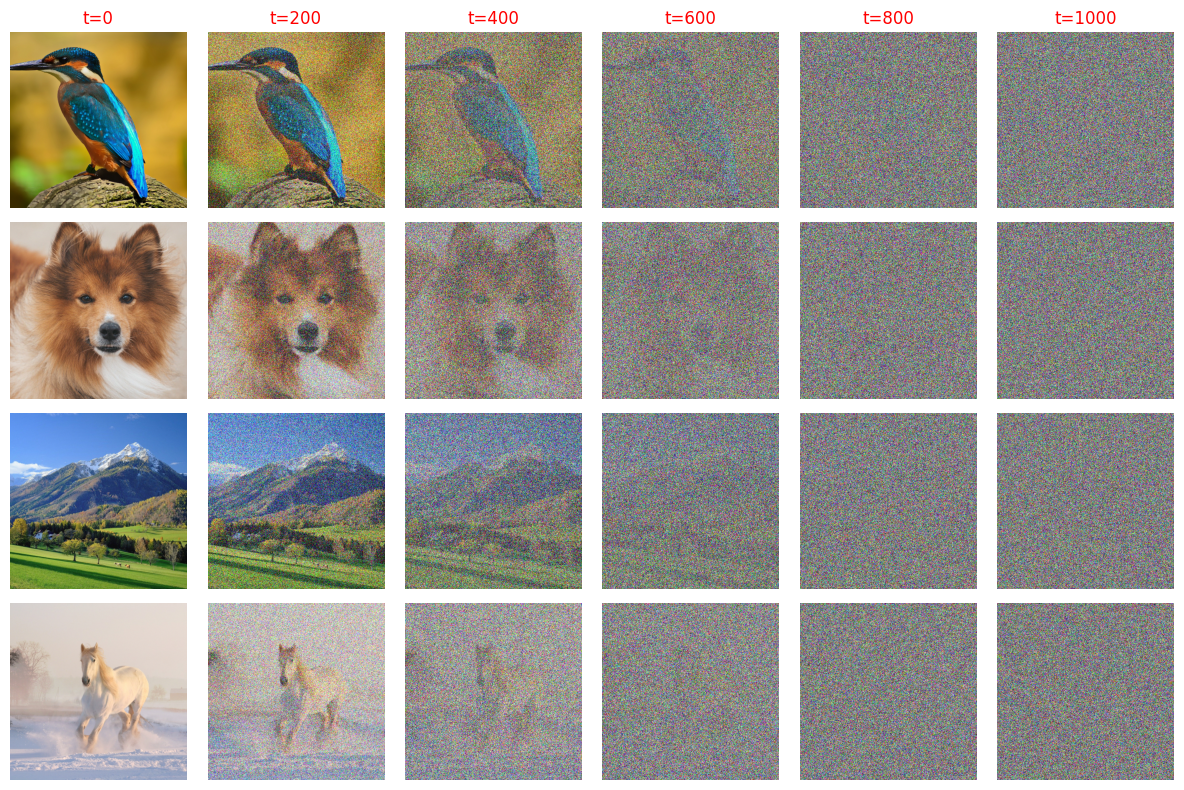

In [6]:
def linear_noisy_image(image, timestep):
  sqrtab = linear_scheduler()['sqrtab'][timestep]
  sqrtmab = linear_scheduler()['sqrtmab'][timestep]
  noisy = image * sqrtab + torch.randn_like(image) * sqrtmab
  return torch.clip(noisy, min=-1, max=1)

imgs = []
for name in ['bird', 'dog', 'mountains', 'horse']:
  img = np.array(PIL.Image.open(f'txt2img/files/{name}.png'))
  img = torch.tensor(2*(img/255) - 1)
  for timestep in [0, 200, 400, 600, 800, 1000]:
    imgs.append(linear_noisy_image(img, timestep)/2 + 0.5)

plt.figure(figsize=(12,8),dpi=100)
for i in range(24):
    plt.subplot(4,6,i+1)    #C
    plt.imshow(imgs[i])
    if i<6:
        plt.title(f't={200*(i%6)}',fontsize=12,c="r")
    plt.axis("off")
plt.tight_layout()
plt.show()

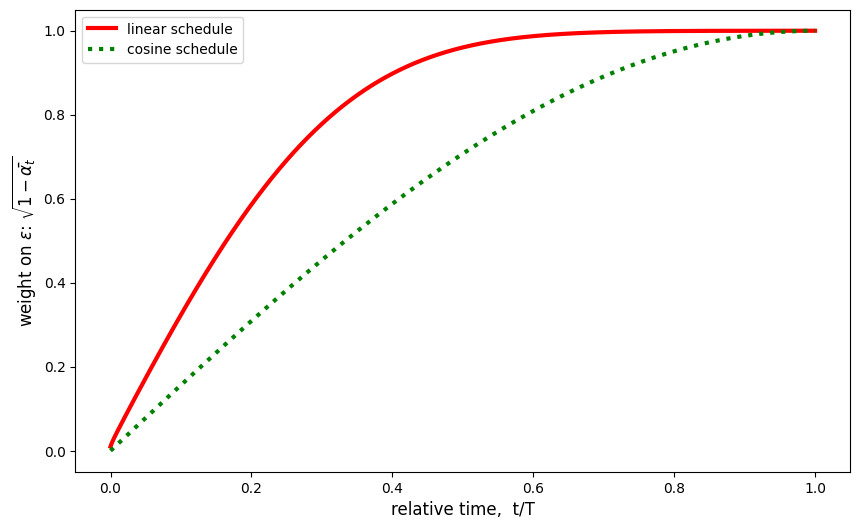

In [7]:
plt.figure(figsize=(10,6),dpi=100)
plt.plot(t, linear_scheduler()["sqrtmab"], linewidth=3,  #2
         linestyle="solid",c="r", label="linear schedule")
plt.plot(t, cosine_scheduler()["sqrtmab"], linewidth=3,  #3
         linestyle="dotted",c="g", label="cosine schedule")
plt.xlabel(r"relative time,  t/T", fontsize=12)
plt.ylabel(r"weight on $\epsilon$: $\sqrt{1-\bar{\alpha_t}}$",
           fontsize=12)
plt.legend()
plt.show()

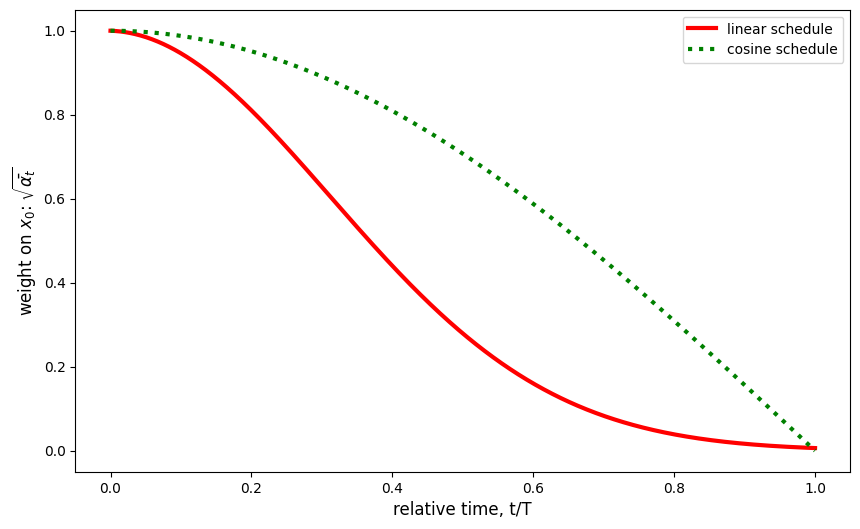

In [8]:
plt.figure(figsize=(10,6),dpi=100)
plt.plot(t, linear_scheduler()["sqrtab"], linewidth=3,  #1
         linestyle="solid",c="r", label="linear schedule")
plt.plot(t, cosine_scheduler()["sqrtab"], linewidth=3,  #2
         linestyle="dotted",c="g", label="cosine schedule")
plt.xlabel(r"relative time, t/T", fontsize=12)
plt.ylabel(r"weight on $x_0$: $\sqrt{\bar{\alpha_t}}$",
           fontsize=12)
plt.legend()
plt.show()

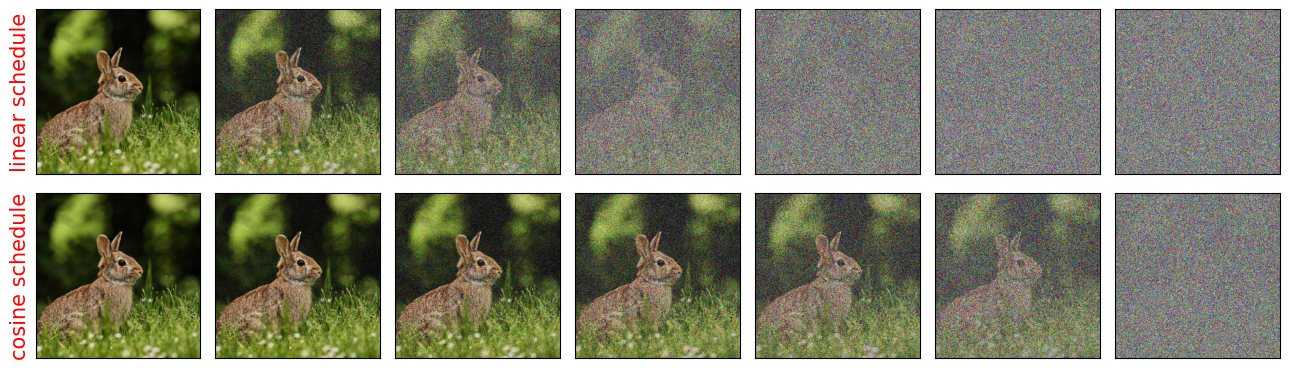

In [9]:
def cosine_noisy_image(image,timestep):  #1
    alphabar_t=cosine_scheduler()["sqrtab"][timestep]
    noisy=image*torch.sqrt(alphabar_t)+\
        torch.randn_like(image)*torch.sqrt(1 - alphabar_t)
    return torch.clip(noisy,min=-1,max=1)

img=np.array(PIL.Image.open("txt2img/files/bunny.png"))
img=torch.tensor(2*(img/255)-1)
imgs=[]

for timestep in [0,166,332,498,664,830,996]:  #2
    imgs.append(linear_noisy_image(img,timestep)/2+0.5)
for timestep in [0,166,332,498,664,830,996]:  #3
    imgs.append(cosine_noisy_image(img,timestep)/2+0.5)

plt.figure(figsize=(13,4),dpi=100)
for i in range(14):  #4
    plt.subplot(2,7,i+1)
    plt.imshow(imgs[i])
    plt.xticks([])
    plt.yticks([])
    if i==0:
        plt.ylabel("linear schedule",fontsize=15,c="r")
    if i==7:
        plt.ylabel("cosine schedule",fontsize=15,c="r")
plt.tight_layout()
plt.show()

In [10]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cuda


In [11]:
model = diffusers.UNet2DModel(sample_size=32,
                              in_channels=1,
                              out_channels=1,
                              layers_per_block=2,
                              block_out_channels=(128, 128, 256, 512),
                              down_block_types =('DownBlock2D', 'DownBlock2D', 'AttnDownBlock2D', 'DownBlock2D'),
                              up_block_types = ('UpBlock2D', 'AttnUpBlock2D', 'UpBlock2D', 'UpBlock2D')).to(device)

In [12]:
torch.manual_seed(42)

In [13]:
tf = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: 2*(x - 0.5))
])

In [14]:
dataset = torchvision.datasets.FashionMNIST(
    r'.',
    train=True,
    download=True,
    transform=tf
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 170kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.16MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.1MB/s]


In [15]:
text_labels=['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']

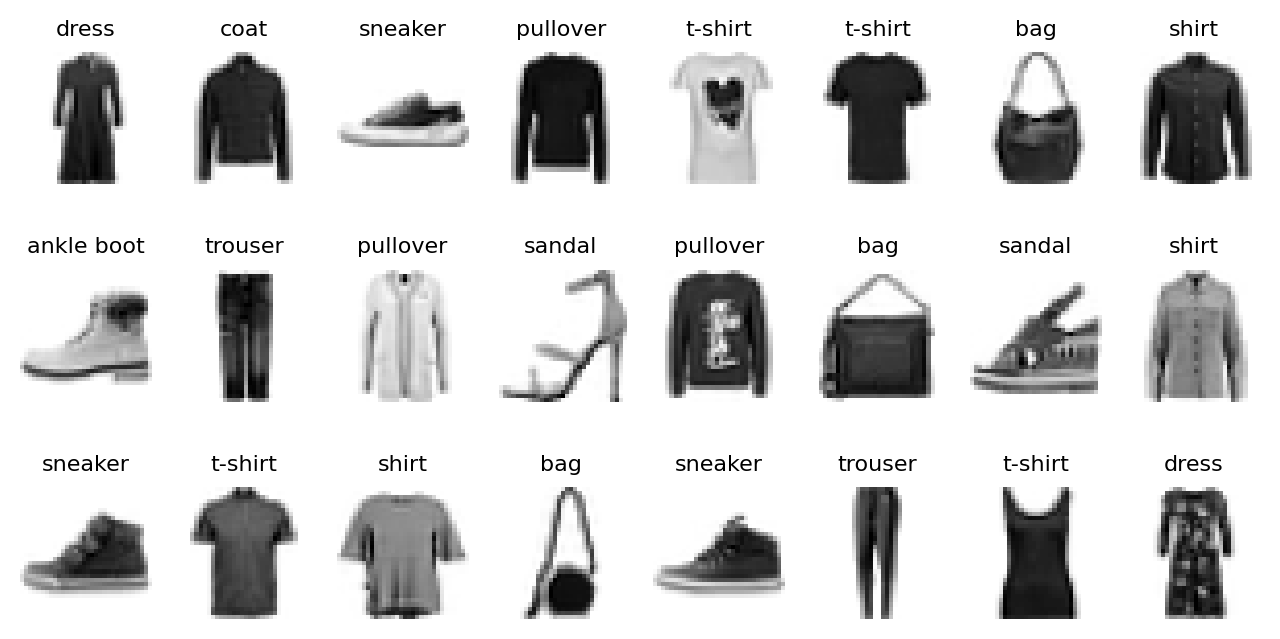

In [16]:
plt.figure(dpi=200,figsize=(8,4))
for i in range(24):
    ax=plt.subplot(3, 8, i + 1)
    img=dataset[i+888][0]
    img=img/2+0.5
    img=img.reshape(32,32)
    plt.imshow(img,
    cmap="binary")
    plt.axis('off')
    plt.title(text_labels[dataset[i+888][1]],fontsize=8)
plt.show()

In [22]:
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

In [23]:
noise_scheduler = diffusers.DDPMScheduler(num_train_timesteps  = 1000, beta_schedule='squaredcos_cap_v2')

In [24]:
@torch.no_grad()
def sample(n_sample, model, noise_scheduler, seed=None):
  if seed is not None:
    torch.manual_seed(seed)
  noise_scheduler.set_timesteps(1000)
  image = torch.randn((n_sample, 1, 32, 32)).to(device)
  for t in noise_scheduler.timesteps:
    model_output = model(image, t)['sample']
    image = noise_scheduler.step(model_output, int(t), image, generator=None)['prev_sample']
  return image

In [25]:
from tqdm import tqdm
from torchvision.utils import save_image, make_grid

In [ ]:
optim = torch.optim.AdamW(model.parameters(), lr=2e-4)

scaler = torch.amp.GradScaler(device)
for i in range(10):
  pbar = tqdm(dataloader)
  loss_ema = None
  for x, _ in pbar:
    x = x.to(device)
    with torch.amp.autocast(device):
      noise = torch.randn_like(x).to(device)
      timesteps = torch.randint(0,
                                noise_scheduler.config.num_train_timesteps,
                                (x.shape[0],),
                                device=device)
      noisy = noise_scheduler.add_noise(x, noise, timesteps)
      noise_pred = model(noisy, timesteps)['sample']
      loss = torch.nn.functional.l1_loss(noise_pred, noise)

    optim.zero_grad()
    scaler.scale(loss).backward()
    scaler.step(optim)
    scaler.update()
    if loss_ema is None:
      loss_ema = loss.item()
    else:
      loss_ema = 0.9 * loss_ema + 0.1 * loss.item()
    pbar.set_description(f'loss: {loss_ema:.4f}')

  xh = sample(32, model, noise_scheduler)
  grid = make_grid(0.5 - xh/2, nrow=8)
  save_image(grid, f'txt2img/files/diffusion_fashion{i}.png')
torch.save(model.state_dict(), 'saved_models/diffusion_fashion.pth')

loss: 0.1217:  32%|███▏      | 75/235 [01:04<02:16,  1.17it/s]

In [ ]:
torch.manual_seed(42)
model.load_state_dict(torch.load(
    "saved_models/diffusion_fashion.pth",
         map_location=device,
         weights_only=True))    #A
generated_images = sample(32, model, noise_scheduler)    #B
grid = make_grid(0.5-generated_images/2, nrow=8)
save_image(grid, f"files/diffusion_fashion.png")
plt.figure(dpi=100)
plt.imshow(grid.cpu().permute(1,2,0))    #C
plt.axis('off')
plt.tight_layout()
plt.show()